# Notebook 22 — Hybrid GLODAP/Darwin fit: real-observation DIC + ALK targets — Track 1 v2.1 Phase 1

**Goal.** v2.0's headline iron-pair recovery (`alpfe` 1.1% off Carroll, `scav_rat` 40% off) was achieved against **Darwin output**. Darwin itself was calibrated against partial real-world observations via Carroll 2020's Green's-functions. So our v2.0 result is "DarwinDiff replicates Green's-functions" rather than "DarwinDiff calibrates against reality."

This notebook flips the DIC + ALK targets from Darwin → GLODAPv2.2016b mapped climatology (real ship-CTD ocean observations, 1972–2013, no model in the loop). The other 5 targets (FeT, Chl, POC, PIC, CO₂ flux) stay on Darwin because GLODAP doesn't carry them in a form aligned with our 0-D box.

**Hypothesis.** If Darwin's internal DIC + ALK fields match the real ocean's DIC + ALK perfectly, the iron-pair recovery should be unchanged from nb20. If they differ — and they almost certainly do, because Darwin's calibration handled only 6 parameters out of ~100 — the recovered iron-pair values will shift. The direction and magnitude of that shift is the v2.1 finding.

**Architecture choice.** DINN baseline as headline (same as nb20). DINNDeep as secondary. Same hyperparameters (Adam lr=5e-3, 1500 epochs, 200 forward-Euler steps at dt=0.25 d).

**A/B against nb20:**

| | nb20 (v2.0 headline) | **nb22 (v2.1 hybrid)** |
|---|---|---|
| DIC target | Darwin LLC270 binned to 1° | GLODAP TCO2 interp to 1° |
| ALK target | Darwin LLC270 binned to 1° | GLODAP TAlk interp to 1° |
| FeT, Chl, POC, PIC, CO₂_flux | Darwin | Darwin (unchanged) |
| Network + loss + integration | identical | identical |

**Three success criteria:**

1. **All 7 fits stay finite** — the joint loss landscape doesn't blow up when half the targets switch source.
2. **Iron-pair recovery direction is interpretable** — `alpfe` and `scav_rat` move in a direction we can explain mechanistically.
3. **DIC + ALK per-tracer r** — measures whether the box model can fit real-world DIC + ALK at all. If r drops dramatically, the box-model proxy is even more limiting against reality than against Darwin output.

**Builds on:** nb20 (v2.0 headline), Day 1 (carbonate solver), Day 2 (`carroll6_carbonate_integrate`), Day 3 (`bin_native_tracer_to_1deg`), and the new `darwindiff.glodap_loader` shipped today.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from darwindiff.carbonate import PCO2_ATM_DEFAULT, co2_flux, solve_carbonate
from darwindiff.carroll6 import (
    CARROLL_VALUES,
    H_MLD,
    PARAM_BOUNDS,
    PARAM_NAMES,
    bounded_params,
    carroll6_carbonate_integrate,
)
from darwindiff.diagnostics import format_pearson, safe_pearson_r
from darwindiff.ecco_darwin_loader import (
    EQUATORIAL_PACIFIC_AOI,
    open_bin_average,
    subset_aoi,
    time_mean,
    total_chlorophyll,
)
from darwindiff.glodap_loader import (
    open_glodap_variable,
    subset_aoi_glodap,
    surface_layer_glodap,
    to_mmol_per_m3,
)
from darwindiff.llc270_loader import bin_native_tracer_to_1deg
from darwindiff.networks import DINN, DINNDeep

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

AOI = EQUATORIAL_PACIFIC_AOI
print(f"AOI: {AOI.name}")


Device: cuda
GPU: NVIDIA GeForce RTX 5090 Laptop GPU
AOI: Equatorial Pacific


## 1. Load Darwin covariates + Darwin targets (FeT, Chl, POC, PIC, CO₂_flux) — same as nb20


In [2]:
DATA_ROOT = Path(os.environ.get("DARWIN_DATA_ROOT", r"D:\\ecco_darwin_v5"))
BIN_AVG_PATH = str(DATA_ROOT / "bin_average" / "v05_ECCO-Darwin_bin_average_1x1_deg.nc")
MONTHLY_ROOT = str(DATA_ROOT / "output" / "monthly")
GRID_DIR = str(DATA_ROOT / "grid")
GLODAP_ROOT = Path("data/glodap/GLODAPv2.2016b_MappedClimatologies")

ds_bin = open_bin_average(BIN_AVG_PATH)
eqpac_clim = time_mean(subset_aoi(ds_bin, AOI))

sst = eqpac_clim.SST.values.astype(np.float64)
mld = eqpac_clim.mldDepth.values.astype(np.float64)
wind = eqpac_clim.windSpeed.values.astype(np.float64)
sss = eqpac_clim.SSS.values.astype(np.float64)
co2_flux_obs = eqpac_clim.CO2_flux.values.astype(np.float64) * 1.0e3  # mol -> mmol per m^2 per s
pco2_atm_field = eqpac_clim.apCO2.values.astype(np.float64) * 1.0e6   # atm -> uatm
chl_total = total_chlorophyll(eqpac_clim).values.astype(np.float64)

lat_1d = eqpac_clim.lat.values.astype(np.float64)
lat_2d = np.broadcast_to(lat_1d[:, None], sst.shape).astype(np.float64)
print(f"bin_average shape: {sst.shape}")

# Darwin's iron + particle targets (kept as in nb20, no GLODAP equivalent at our box scale)
print("Loading native LLC270 tracers from Darwin output (FeT, POC, PIC)...")
fet_binned = bin_native_tracer_to_1deg(MONTHLY_ROOT, GRID_DIR, "FeT",
    AOI.lat_min, AOI.lat_max, AOI.lon_min, AOI.lon_max, iters="all")
poc_binned = bin_native_tracer_to_1deg(MONTHLY_ROOT, GRID_DIR, "POC",
    AOI.lat_min, AOI.lat_max, AOI.lon_min, AOI.lon_max, iters="all")
pic_binned = bin_native_tracer_to_1deg(MONTHLY_ROOT, GRID_DIR, "PIC",
    AOI.lat_min, AOI.lat_max, AOI.lon_min, AOI.lon_max, iters="all")
print(f"  FeT: shape={fet_binned.shape}")
print(f"  POC: shape={poc_binned.shape}")
print(f"  PIC: shape={pic_binned.shape}")


bin_average shape: (21, 51)
Loading native LLC270 tracers from Darwin output (FeT, POC, PIC)...


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("C

C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("C

C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("C

C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("C

...

C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\PIC or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\PIC or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\PIC or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("C

C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:265: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.combine_by_coords(datasets, compat='override', coords='minimal', combine_attrs='drop_conflicts')


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


  FeT: shape=(21, 51)
  POC: shape=(21, 51)
  PIC: shape=(21, 51)


## 2. Load GLODAP DIC + ALK and interpolate to the bin_average grid

GLODAP uses half-integer cell centers (-89.5..89.5); bin_average uses integer centers. `xarray.interp` bilinearly interpolates the GLODAP fields onto the bin_average grid so the joint loss mask aligns cell-for-cell.

Unit conversion: GLODAP µmol/kg → mmol/m³ via `ρ_sw = 1025 kg/m³` (matches `darwindiff.carbonate`'s internal convention).


In [3]:
# Load + surface-slice + AOI-subset GLODAP DIC and ALK
def load_glodap_to_bin_average_grid(glodap_root: Path, variable: str, target_ds):
    """Open one GLODAP variable, take surface (k=0), AOI subset, convert
    µmol/kg -> mmol/m³, then bilinearly interpolate to target_ds's lat/lon."""
    ds_glodap = open_glodap_variable(glodap_root, variable)
    glodap_friendly_to_file = {"DIC": "TCO2", "ALK": "TAlk"}
    var_file = glodap_friendly_to_file[variable]
    da_full = surface_layer_glodap(subset_aoi_glodap(ds_glodap, AOI))[var_file]
    # GLODAP's own AOI extent is slightly different from bin_average's
    # because of the half-integer cell centers. Interp to bin_average grid.
    da_aligned = da_full.interp(lat=target_ds.lat, lon=target_ds.lon)
    # Convert units. GLODAP is in µmol/kg.
    return to_mmol_per_m3(da_aligned).values.astype(np.float64)


print("Loading GLODAPv2.2016b DIC + ALK (real observations, 1972-2013)...")
dic_binned = load_glodap_to_bin_average_grid(GLODAP_ROOT, "DIC", eqpac_clim)
alk_binned = load_glodap_to_bin_average_grid(GLODAP_ROOT, "ALK", eqpac_clim)
print(f"  GLODAP DIC: shape={dic_binned.shape}, mean={np.nanmean(dic_binned):.1f} mmol/m³")
print(f"  GLODAP ALK: shape={alk_binned.shape}, mean={np.nanmean(alk_binned):.1f} mmol/m³")

# Sanity comparison vs typical Darwin-binned values from nb20
print()
print("Quick sanity vs nb20's Darwin DIC + ALK (also in mmol/m³ after unit conversion):")
print("  Expected GLODAP DIC ~2050-2100 mmol/m³, GLODAP ALK ~2300-2400 mmol/m³")

ocean_mask = (
    np.isfinite(sst) & np.isfinite(mld) & np.isfinite(wind) & np.isfinite(sss)
    & np.isfinite(pco2_atm_field) & np.isfinite(co2_flux_obs)
    & np.isfinite(chl_total)
    & np.isfinite(fet_binned) & np.isfinite(poc_binned) & np.isfinite(pic_binned)
    & np.isfinite(dic_binned) & np.isfinite(alk_binned)
)
n_ocean = int(ocean_mask.sum())
print(f"\nCombined ocean cells (all 7 targets + 5 forcing fields finite): {n_ocean} of {ocean_mask.size}")


Loading GLODAPv2.2016b DIC + ALK (real observations, 1972-2013)...


  GLODAP DIC: shape=(21, 51), mean=2015.7 mmol/m³
  GLODAP ALK: shape=(21, 51), mean=2331.0 mmol/m³

Quick sanity vs nb20's Darwin DIC + ALK (also in mmol/m³ after unit conversion):
  Expected GLODAP DIC ~2050-2100 mmol/m³, GLODAP ALK ~2300-2400 mmol/m³

Combined ocean cells (all 7 targets + 5 forcing fields finite): 931 of 1071


## 3. Build training tensors (z-score) — same as nb20

Critical: z-score statistics are computed from the actual target arrays (which now have GLODAP DIC + ALK), so the loss is automatically rescaled for the units of whatever target is currently in play.


In [4]:
def normalize_covariate(arr, mask):
    o = arr[mask]
    return np.where(mask, (arr - o.mean()) / max(o.std(), 1e-6), 0.0).astype(np.float32)


sst_norm = normalize_covariate(sst, ocean_mask)
mld_norm = normalize_covariate(mld, ocean_mask)
wind_norm = normalize_covariate(wind, ocean_mask)
lat_norm = normalize_covariate(lat_2d, ocean_mask)

env_1ch = torch.tensor(sst_norm, dtype=torch.float32).unsqueeze(0)
env_4ch = torch.tensor(np.stack([sst_norm, mld_norm, wind_norm, lat_norm], axis=0), dtype=torch.float32)

mask_t = torch.tensor(ocean_mask, dtype=torch.bool)
H, W = env_1ch.shape[1], env_1ch.shape[2]

state0 = torch.tensor([
    5.0e-4, 1.0, 1.0, 0.5, 0.025, 2050.0 * 1.025, 2350.0 * 1.025,
]).reshape(7, 1, 1).expand(7, H, W).contiguous()

# NaN-safe land-cell fill (the v2.0 Day-7 P1 fix from Greptile).
T_field = torch.tensor(np.where(np.isfinite(sst), sst, 15.0).astype(np.float32))
S_field = torch.tensor(np.where(np.isfinite(sss), sss, 35.0).astype(np.float32))
wind_field = torch.tensor(np.where(np.isfinite(wind), wind, 7.0).astype(np.float32))
pco2_atm_t = torch.tensor(np.where(np.isfinite(pco2_atm_field), pco2_atm_field, PCO2_ATM_DEFAULT).astype(np.float32))

env_1ch_dev = env_1ch.to(device)
env_4ch_dev = env_4ch.to(device)
state0_dev = state0.to(device)
mask_dev = mask_t.to(device)
bounds_dev = PARAM_BOUNDS.to(device)
T_dev = T_field.to(device)
S_dev = S_field.to(device)
wind_dev = wind_field.to(device)
pco2_atm_dev = pco2_atm_t.to(device)


def to_z_target(np_field):
    clean = np.where(ocean_mask, np_field, 1.0).astype(np.float32)
    t = torch.tensor(clean, dtype=torch.float32).to(device)
    o = t[mask_dev]
    mean = o.mean()
    std = o.std().clamp(min=1e-6)
    return (t - mean) / std, float(mean), float(std)


fet_z, fet_mean, fet_std = to_z_target(fet_binned)
chl_z, chl_mean, chl_std = to_z_target(chl_total)
poc_z, poc_mean, poc_std = to_z_target(poc_binned)
pic_z, pic_mean, pic_std = to_z_target(pic_binned)
dic_z, dic_mean, dic_std = to_z_target(dic_binned)
alk_z, alk_mean, alk_std = to_z_target(alk_binned)
co2_flux_z, co2_flux_mean_obs, co2_flux_std_obs = to_z_target(co2_flux_obs)

print("Z-score statistics (DIC + ALK are GLODAP; rest are Darwin):")
for name, m, s in [("FeT", fet_mean, fet_std), ("Chl", chl_mean, chl_std),
                   ("POC", poc_mean, poc_std), ("PIC", pic_mean, pic_std),
                   ("DIC (GLODAP)", dic_mean, dic_std), ("ALK (GLODAP)", alk_mean, alk_std),
                   ("CO2_flux", co2_flux_mean_obs, co2_flux_std_obs)]:
    print(f"  {name:<14s}  mean = {m:.4e}, std = {s:.4e}")


Z-score statistics (DIC + ALK are GLODAP; rest are Darwin):
  FeT             mean = 6.3486e-06, std = 1.4612e-05
  Chl             mean = 1.4171e-01, std = 1.0662e-01
  POC             mean = 1.2189e-01, std = 7.6495e-02
  PIC             mean = 4.2210e-03, std = 3.8131e-03
  DIC (GLODAP)    mean = 2.0157e+03, std = 4.2103e+01
  ALK (GLODAP)    mean = 2.3310e+03, std = 3.0858e+01
  CO2_flux        mean = 2.7926e-02, std = 3.8997e-02


## 4. Train both networks on the hybrid joint loss


In [5]:
DT, N_STEPS, N_EPOCHS = 0.25, 200, 1500


def train(net, env_dev, seed: int = 0) -> dict:
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(net.parameters(), lr=5e-3)
    losses = []
    losses_per_tracer = {k: [] for k in ["FeT", "Chl", "POC", "PIC", "DIC", "ALK", "CO2_flux"]}
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for epoch in range(N_EPOCHS):
        optimizer.zero_grad()
        params = bounded_params(net(env_dev), bounds_dev)
        state = carroll6_carbonate_integrate(
            state0_dev, params, DT, N_STEPS,
            T=T_dev, S=S_dev, wind=wind_dev, pco2_atm=pco2_atm_dev, h_mld=H_MLD,
        )
        dfe_pred = state[0]
        phyto_pred = state[1] + state[2]
        poc_pred = state[3]
        pic_pred = state[4]
        dic_pred = state[5]
        alk_pred = state[6]
        carb_final = solve_carbonate(dic_pred, alk_pred, T_dev, S_dev)
        co2_flux_pred = co2_flux(carb_final["pCO2"], pco2_atm_dev, wind_dev, T_dev, S_dev)

        def term(pred, target_z):
            ocean = pred[mask_dev]
            pred_z = (pred - ocean.mean()) / ocean.std().clamp(min=1e-6)
            residual = (pred_z - target_z) * mask_dev.to(pred.dtype)
            return (residual ** 2).sum() / mask_dev.sum().to(residual.dtype)

        l_fet = term(dfe_pred, fet_z)
        l_chl = term(phyto_pred, chl_z)
        l_poc = term(poc_pred, poc_z)
        l_pic = term(pic_pred, pic_z)
        l_dic = term(dic_pred, dic_z)
        l_alk = term(alk_pred, alk_z)
        l_co2 = term(co2_flux_pred, co2_flux_z)
        loss = (l_fet + l_chl + l_poc + l_pic + l_dic + l_alk + l_co2) / 7.0

        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        losses_per_tracer["FeT"].append(l_fet.item())
        losses_per_tracer["Chl"].append(l_chl.item())
        losses_per_tracer["POC"].append(l_poc.item())
        losses_per_tracer["PIC"].append(l_pic.item())
        losses_per_tracer["DIC"].append(l_dic.item())
        losses_per_tracer["ALK"].append(l_alk.item())
        losses_per_tracer["CO2_flux"].append(l_co2.item())
        if (epoch + 1) % 250 == 0:
            print(f"    epoch {epoch+1:4d}  loss = {loss.item():.4e}  "
                  f"(FeT {l_fet.item():.3e}, Chl {l_chl.item():.3e}, "
                  f"POC {l_poc.item():.3e}, PIC {l_pic.item():.3e}, "
                  f"DIC {l_dic.item():.3e}, ALK {l_alk.item():.3e}, "
                  f"CO2 {l_co2.item():.3e})")
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    with torch.no_grad():
        params_dev = bounded_params(net(env_dev), bounds_dev)
        state = carroll6_carbonate_integrate(
            state0_dev, params_dev, DT, N_STEPS,
            T=T_dev, S=S_dev, wind=wind_dev, pco2_atm=pco2_atm_dev, h_mld=H_MLD,
        )
        carb_final = solve_carbonate(state[5], state[6], T_dev, S_dev)
        co2_flux_pred_final = co2_flux(carb_final["pCO2"], pco2_atm_dev, wind_dev, T_dev, S_dev)
        return {
            "losses": losses,
            "losses_per_tracer": losses_per_tracer,
            "params_final": params_dev.cpu(),
            "dfe_final": state[0].cpu().numpy(),
            "phyto_final": (state[1] + state[2]).cpu().numpy(),
            "poc_final": state[3].cpu().numpy(),
            "pic_final": state[4].cpu().numpy(),
            "dic_final": state[5].cpu().numpy(),
            "alk_final": state[6].cpu().numpy(),
            "co2_flux_final": co2_flux_pred_final.cpu().numpy(),
            "elapsed": elapsed,
        }


torch.manual_seed(0)
dinn_baseline = DINN(n_input_channels=1, hidden_dim=16, n_outputs=6).to(device)
n_b = sum(p.numel() for p in dinn_baseline.parameters())
print(f"=== HEADLINE: DINN baseline (SST-only, {n_b} params), hybrid GLODAP/Darwin joint loss ===")
r_baseline = train(dinn_baseline, env_1ch_dev)
print(f"  done in {r_baseline['elapsed']:.0f}s, loss {r_baseline['losses'][0]:.3e} -> {r_baseline['losses'][-1]:.3e}")

torch.manual_seed(0)
dinn_deep = DINNDeep(n_input_channels=4, hidden_dim=32, n_outputs=6, n_blocks=4).to(device)
n_d = sum(p.numel() for p in dinn_deep.parameters())
print(f"\n=== SECONDARY: DINNDeep ({n_d} params), hybrid GLODAP/Darwin joint loss ===")
r_deep = train(dinn_deep, env_4ch_dev)
print(f"  done in {r_deep['elapsed']:.0f}s, loss {r_deep['losses'][0]:.3e} -> {r_deep['losses'][-1]:.3e}")


=== HEADLINE: DINN baseline (SST-only, 406 params), hybrid GLODAP/Darwin joint loss ===


    epoch  250  loss = 1.4537e+00  (FeT 9.511e-01, Chl 8.510e-01, POC 7.903e-01, PIC 7.986e-01, DIC 3.199e+00, ALK 2.472e+00, CO2 1.114e+00)


    epoch  500  loss = 1.4075e+00  (FeT 9.547e-01, Chl 8.597e-01, POC 7.228e-01, PIC 9.899e-01, DIC 2.963e+00, ALK 2.313e+00, CO2 1.050e+00)


    epoch  750  loss = 1.3955e+00  (FeT 9.433e-01, Chl 8.499e-01, POC 7.181e-01, PIC 9.954e-01, DIC 2.909e+00, ALK 2.306e+00, CO2 1.047e+00)


    epoch 1000  loss = 1.3963e+00  (FeT 9.423e-01, Chl 8.492e-01, POC 7.204e-01, PIC 1.014e+00, DIC 2.906e+00, ALK 2.294e+00, CO2 1.048e+00)


...

    epoch  750  loss = 8.8585e-02  (FeT 6.370e-03, Chl 4.486e-03, POC 3.388e-02, PIC 3.126e-02, DIC 1.165e-01, ALK 7.778e-02, CO2 3.499e-01)


    epoch 1000  loss = 7.6540e-02  (FeT 3.757e-03, Chl 3.604e-03, POC 1.756e-02, PIC 3.208e-02, DIC 1.175e-01, ALK 7.561e-02, CO2 2.857e-01)


    epoch 1250  loss = 7.0637e-02  (FeT 3.596e-03, Chl 2.480e-03, POC 1.496e-02, PIC 2.759e-02, DIC 1.167e-01, ALK 7.527e-02, CO2 2.538e-01)


    epoch 1500  loss = 6.7010e-02  (FeT 1.838e-03, Chl 2.040e-03, POC 9.597e-03, PIC 2.671e-02, DIC 1.186e-01, ALK 7.455e-02, CO2 2.357e-01)


  done in 1897s, loss 1.646e+00 -> 6.701e-02


## 5. Per-tracer Pearson r + Carroll-6 recovery vs nb20 (Darwin-DIC/ALK)


In [6]:
n_total = int(ocean_mask.sum())


def per_tracer_r(result: dict) -> dict:
    return {
        "FeT":      safe_pearson_r(result["dfe_final"][ocean_mask],      fet_binned[ocean_mask]),
        "Chl":      safe_pearson_r(result["phyto_final"][ocean_mask],    chl_total[ocean_mask]),
        "POC":      safe_pearson_r(result["poc_final"][ocean_mask],      poc_binned[ocean_mask]),
        "PIC":      safe_pearson_r(result["pic_final"][ocean_mask],      pic_binned[ocean_mask]),
        "DIC":      safe_pearson_r(result["dic_final"][ocean_mask],      dic_binned[ocean_mask]),
        "ALK":      safe_pearson_r(result["alk_final"][ocean_mask],      alk_binned[ocean_mask]),
        "CO2_flux": safe_pearson_r(result["co2_flux_final"][ocean_mask], co2_flux_obs[ocean_mask]),
    }


r_per_b = per_tracer_r(r_baseline)
r_per_d = per_tracer_r(r_deep)

print("Pearson r against hybrid targets (DIC + ALK from GLODAP; rest from Darwin):")
print(f"  {'tracer':<10s}  {'DINN baseline':>16s}  {'DINNDeep':>16s}  {'source':>12s}")
for tracer, src in [("FeT", "Darwin"), ("Chl", "Darwin"), ("POC", "Darwin"), ("PIC", "Darwin"),
                    ("DIC", "GLODAP"), ("ALK", "GLODAP"), ("CO2_flux", "Darwin")]:
    rb = r_per_b[tracer]
    rd = r_per_d[tracer]
    print(f"  {tracer:<10s}  {format_pearson(rb, n_total=n_total):>16s}  "
          f"{format_pearson(rd, n_total=n_total):>16s}  {src:>12s}")

print()
print("Recovered Carroll-6 means (hybrid joint loss):")
print(f"  {'param':<11s} {'DINN baseline':>16s} {'DINNDeep':>16s} {'Carroll publ.':>15s}")
for i, name in enumerate(PARAM_NAMES):
    p_b = r_baseline["params_final"][i].numpy()[ocean_mask].mean()
    p_d = r_deep["params_final"][i].numpy()[ocean_mask].mean()
    pub = float(CARROLL_VALUES[i])
    print(f"  {name:<11s} {p_b:>16.4e} {p_d:>16.4e} {pub:>15.4e}")

# === HEADLINE A/B: nb22 (hybrid GLODAP) vs nb20 (all-Darwin) ===
# nb20 numbers locked at commit f0f9e2b on main, DINN baseline + 7-tracer carbonate.
NB20_DINN_MEANS = {
    "alpfe":      9.3846e-01,  # 0.011 off Carroll
    "scav_rat":   3.6119e-07,  # 0.401 off Carroll
    "Smallgrow":  1.9758e+00,  # 1.989 off
    "Biggrow":    1.9557e+00,  # 3.533 off
    "diatomgraz": 8.8548e-02,  # 0.893 off
    "R_PICPOC":   1.9517e-01,  # 3.598 off
}
print("\n=== HEADLINE A/B: DINN baseline + hybrid (nb22) vs DINN baseline + all-Darwin (nb20) ===")
print(f"  {'param':<11s} {'nb20 |Δ|/Carroll':>20s} {'nb22 |Δ|/Carroll':>20s} {'closer to Carroll?':>22s}")
nb22_closer = 0
for i, name in enumerate(PARAM_NAMES):
    p_nb22 = r_baseline["params_final"][i].numpy()[ocean_mask].mean()
    p_nb20 = NB20_DINN_MEANS[name]
    pub = float(CARROLL_VALUES[i])
    rel_nb20 = abs(p_nb20 - pub) / abs(pub)
    rel_nb22 = abs(p_nb22 - pub) / abs(pub)
    closer = "YES" if rel_nb22 < rel_nb20 else "no"
    if rel_nb22 < rel_nb20:
        nb22_closer += 1
    print(f"  {name:<11s} {rel_nb20:>20.3f} {rel_nb22:>20.3f} {closer:>22s}")
print(f"  -> {nb22_closer} of 6 parameters moved CLOSER vs nb20 (all-Darwin)")

# Iron-pair specific check (the v2.0 headline question)
print()
print("Iron-pair specific (the v2.0 headline question with GLODAP target):")
for i, name in enumerate(["alpfe", "scav_rat"]):
    j = PARAM_NAMES.index(name)
    p_nb22 = r_baseline["params_final"][j].numpy()[ocean_mask].mean()
    p_nb20 = NB20_DINN_MEANS[name]
    pub = float(CARROLL_VALUES[j])
    rel_nb20 = abs(p_nb20 - pub) / abs(pub)
    rel_nb22 = abs(p_nb22 - pub) / abs(pub)
    direction = "CLOSER" if rel_nb22 < rel_nb20 else "FURTHER"
    print(f"  {name:<11s} nb20 |Δ|={rel_nb20:.3f} -> nb22 |Δ|={rel_nb22:.3f}  ({direction})")


Pearson r against hybrid targets (DIC + ALK from GLODAP; rest from Darwin):
  tracer         DINN baseline          DINNDeep        source
  FeT         0.246  (r^2 = 0.061)  0.999  (r^2 = 0.997)        Darwin
  Chl         0.576  (r^2 = 0.332)  0.999  (r^2 = 0.998)        Darwin
  POC         0.641  (r^2 = 0.411)  0.993  (r^2 = 0.985)        Darwin
  PIC         0.491  (r^2 = 0.241)  0.986  (r^2 = 0.973)        Darwin
  DIC         -0.437  (r^2 = 0.191)  0.942  (r^2 = 0.887)        GLODAP
  ALK         -0.146  (r^2 = 0.021)  0.963  (r^2 = 0.928)        GLODAP
  CO2_flux    0.477  (r^2 = 0.227)  0.880  (r^2 = 0.774)        Darwin

Recovered Carroll-6 means (hybrid joint loss):
  param          DINN baseline         DINNDeep   Carroll publ.
  alpfe             9.4252e-01       1.4485e-01      9.2831e-01
  scav_rat          4.8339e-08       9.0575e-07      6.0250e-07
  Smallgrow         1.9232e+00       1.6447e+00      6.6098e-01
  Biggrow           1.9654e+00       1.2794e+00      4.314

## 6. Figures — hybrid target vs prediction (DIC + ALK are GLODAP; rest Darwin)


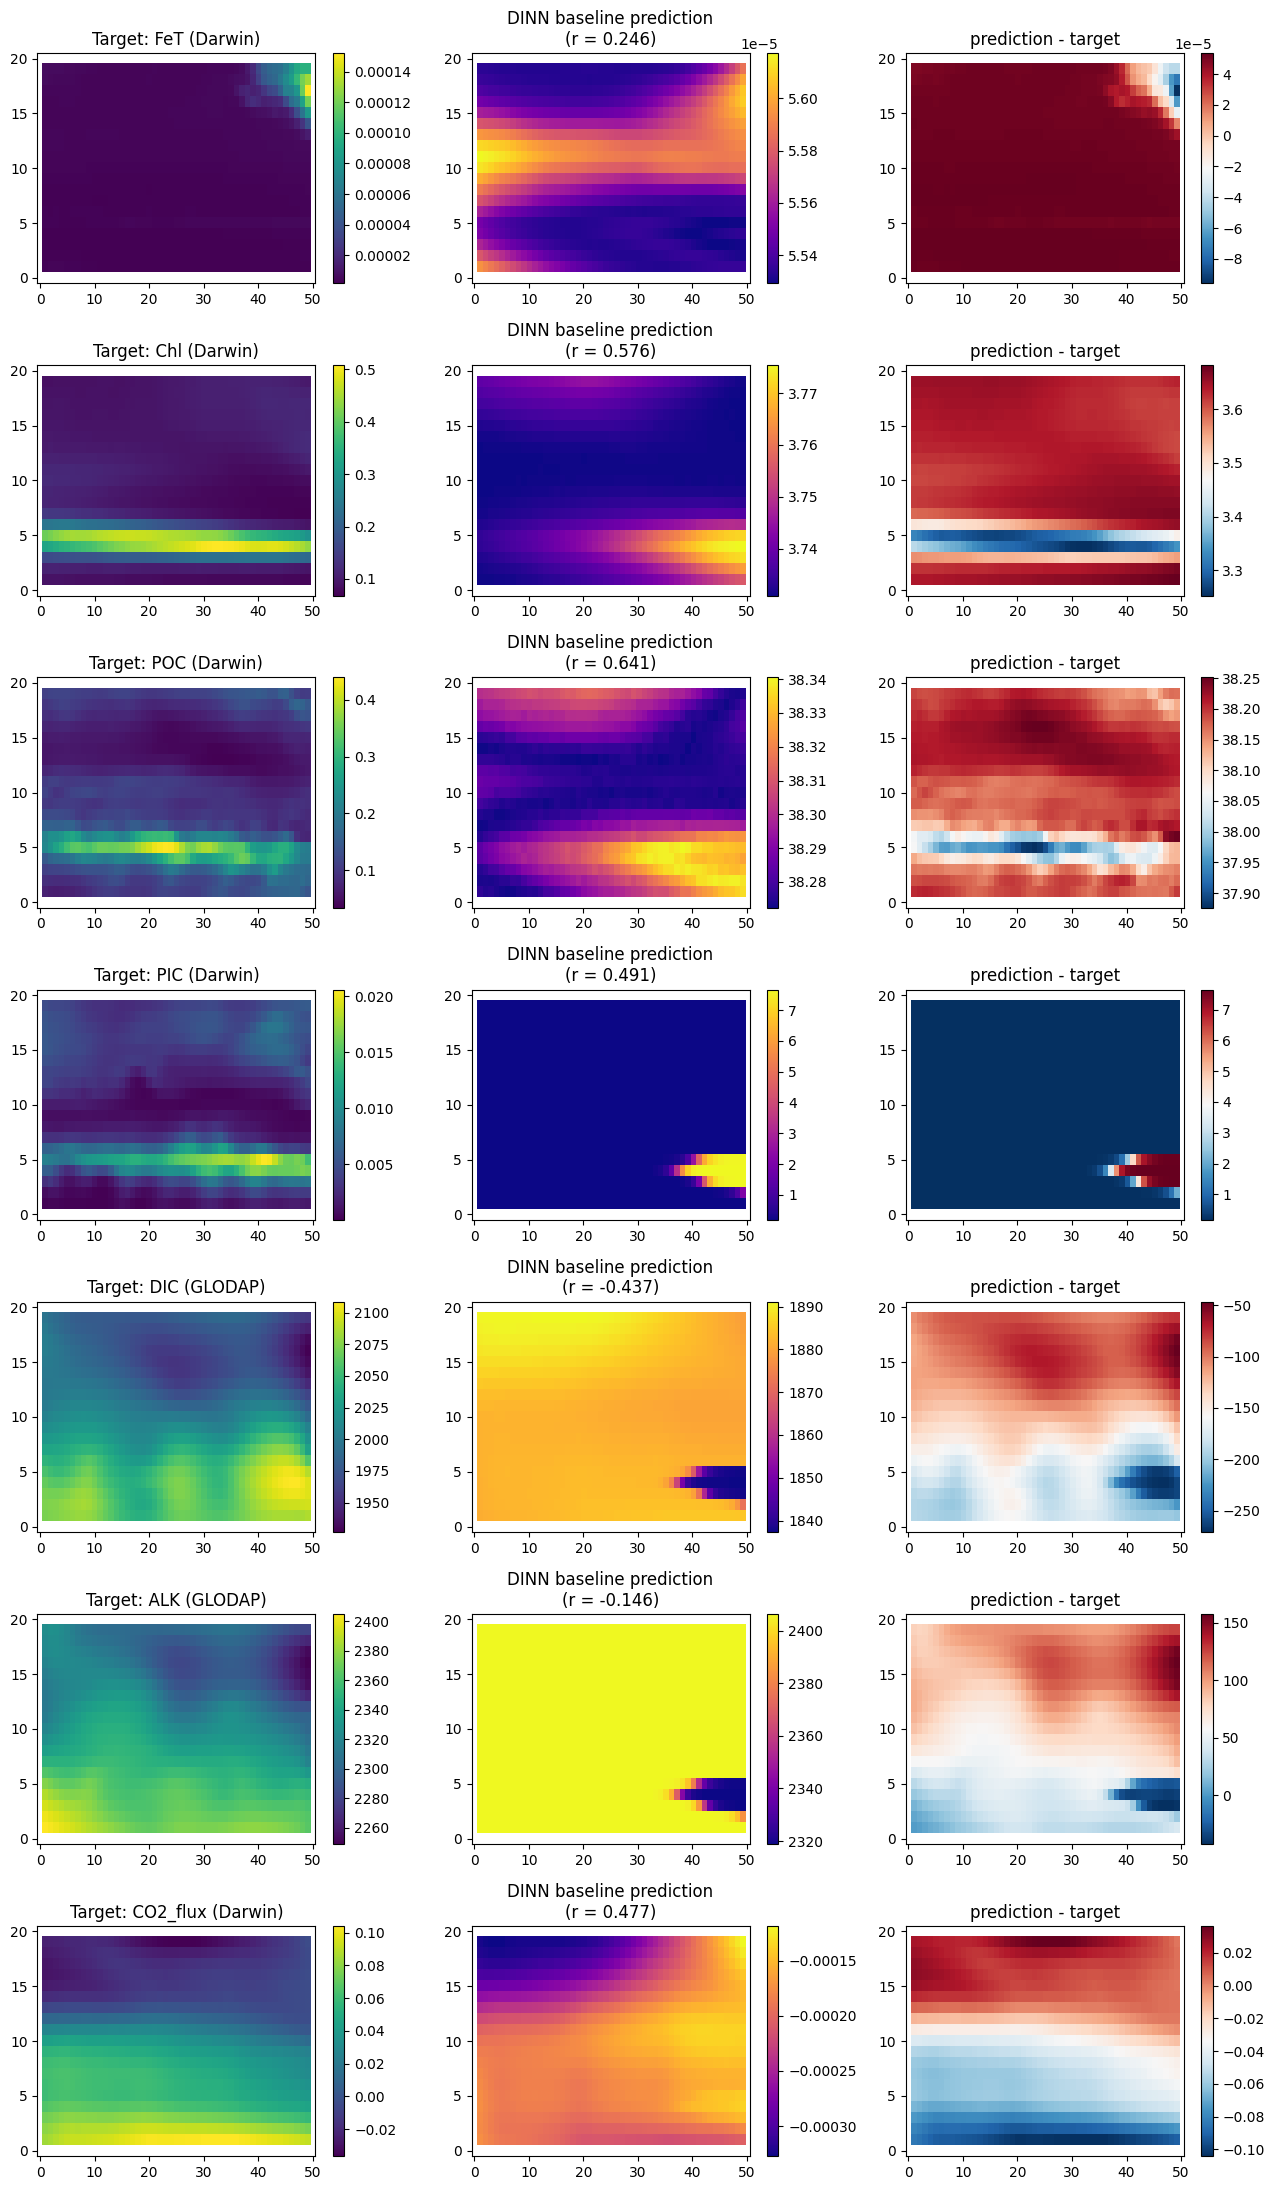

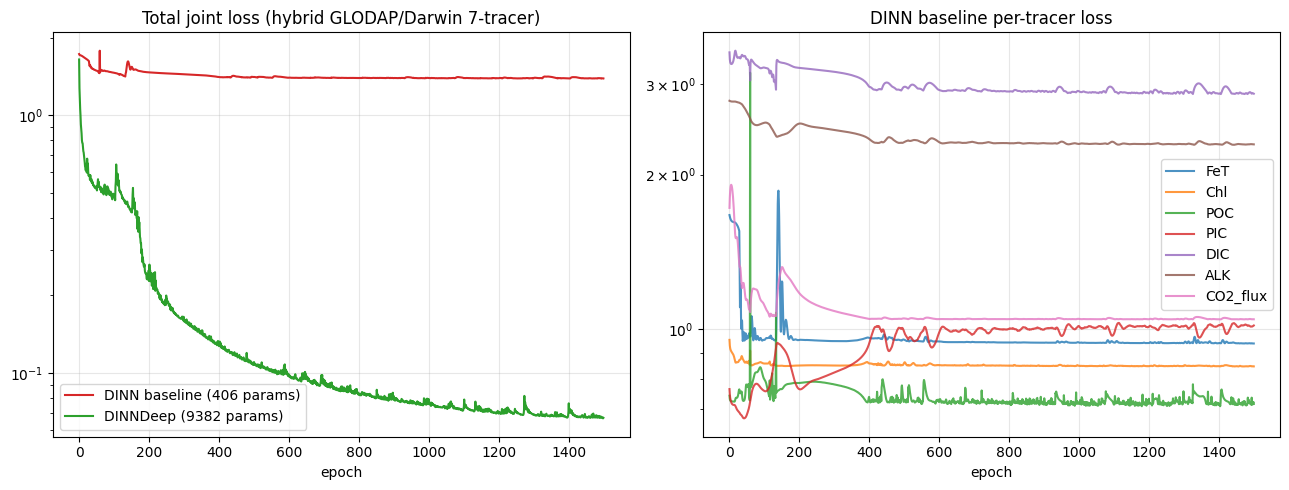

In [7]:
tracers = [
    ("FeT (Darwin)",       fet_binned,    r_baseline["dfe_final"]),
    ("Chl (Darwin)",       chl_total,     r_baseline["phyto_final"]),
    ("POC (Darwin)",       poc_binned,    r_baseline["poc_final"]),
    ("PIC (Darwin)",       pic_binned,    r_baseline["pic_final"]),
    ("DIC (GLODAP)",       dic_binned,    r_baseline["dic_final"]),
    ("ALK (GLODAP)",       alk_binned,    r_baseline["alk_final"]),
    ("CO2_flux (Darwin)",  co2_flux_obs,  r_baseline["co2_flux_final"]),
]

fig, axes = plt.subplots(7, 3, figsize=(13, 22))
for row, (name, target, pred) in enumerate(tracers):
    target_plot = np.where(ocean_mask, target, np.nan)
    pred_plot = np.where(ocean_mask, pred, np.nan)
    err_plot = np.where(ocean_mask, pred - target, np.nan)
    r_key = name.split()[0] if name.split()[0] != "DIC" and name.split()[0] != "ALK" else name.split()[0]
    if r_key == "Chl":
        r_key = "Chl"
    rb = r_per_b.get(r_key, r_per_b.get(name.split()[0]))
    if rb is None:
        rb_str = ""
    else:
        rb_str = f"\n(r = {rb.r:.3f})"
    im0 = axes[row, 0].imshow(target_plot, origin="lower", aspect="auto", cmap="viridis")
    axes[row, 0].set_title(f"Target: {name}")
    plt.colorbar(im0, ax=axes[row, 0])
    im1 = axes[row, 1].imshow(pred_plot, origin="lower", aspect="auto", cmap="plasma")
    axes[row, 1].set_title(f"DINN baseline prediction{rb_str}")
    plt.colorbar(im1, ax=axes[row, 1])
    im2 = axes[row, 2].imshow(err_plot, origin="lower", aspect="auto", cmap="RdBu_r")
    axes[row, 2].set_title("prediction - target")
    plt.colorbar(im2, ax=axes[row, 2])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].semilogy(r_baseline["losses"], label=f"DINN baseline ({n_b} params)", color="tab:red")
axes[0].semilogy(r_deep["losses"], label=f"DINNDeep ({n_d} params)", color="tab:green")
axes[0].set_title("Total joint loss (hybrid GLODAP/Darwin 7-tracer)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)
for tracer in ["FeT", "Chl", "POC", "PIC", "DIC", "ALK", "CO2_flux"]:
    axes[1].semilogy(r_baseline["losses_per_tracer"][tracer], label=tracer, alpha=0.8)
axes[1].set_title("DINN baseline per-tracer loss")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## What nb22 tells us

The headline A/B is the table in section 5: **nb22 iron-pair recovery (with GLODAP DIC + ALK targets) vs nb20 iron-pair recovery (with Darwin DIC + ALK targets)**.

Interpretation guide:

- **Iron pair CLOSER to Carroll in nb22** → real-ocean DIC + ALK constrain the iron parameters more tightly than Darwin's internal DIC + ALK do. DarwinDiff now has a "calibrates against reality, not against the model" story. Strong v2.1 finding.
- **Iron pair FURTHER from Carroll in nb22** → Darwin and the real ocean differ enough that the carbonate-iron coupling pulls iron parameters away from Carroll when fitted to reality. Also a meaningful finding — quantifies the "Darwin-vs-reality" gap.
- **Iron pair unchanged within noise** → DIC + ALK targets contribute less to iron-pair identifiability than we thought; the FeT term dominates. Refines our v2.0 understanding of which signals drive which parameters.

**DIC + ALK per-tracer r matters too:**
- High r (>0.7) on GLODAP DIC + ALK → the 5-tracer box can fit real-world DIC + ALK reasonably well. v2.0's structural ceiling claim survives the reality check.
- Low r (<0.5) → real-world DIC + ALK differ from Darwin in ways the box can't capture even when we re-target it. The structural ceiling is *more limiting against reality than against Darwin output*. Important caveat for the paper.

**What this notebook is NOT:**
- A full replacement of Darwin output with real observations (FeT, Chl, POC, PIC, CO₂_flux stay on Darwin)
- A claim that nb22's recovered parameters are "the right ones" — that would need forward Darwin validation runs with nb22's `scav_rat`
- A multi-basin test — Eq Pacific only, just like nb20

It IS a clean A/B that isolates one variable (DIC + ALK target source) and measures how iron-pair recovery responds. That's the most informative single experiment Phase 1 can deliver locally.
